# Notebook 6 (V4_3) — Bubble-Driven US NFA Decomposition

**The project's ultimate goal:** use the two-country *production* model to
measure how the US per-variety stock **bubble** contributes to (negative) US
**net foreign assets**. This notebook ports the endowment-economy analysis
(`04_bubble_diagnostics.ipynb` §3–4 and `06_nfa_decomposition.ipynb`) to the
V4_3 production economy (`Reference_draft/V4_3_production.tex`).

### Method
1. **Fundamental value** of the per-variety US stock by backward recursion with
   the *effective* kernel $\mathcal M_{t,t+1}=\mathcal K_{t,t+1}/\Psi_t$
   (V4_3 `effective_US_kernel`, lines 1115–1207):
   $$q_{US,t}=v_{US,t}+B_{US,t},\qquad
     v_{US,t}=E_t\!\Big[\sum_{s\ge1}\mathcal M_{t,t+s}d_{US,t+s}\Big],\qquad
     B_{US,t}=\lim_T E_t[\mathcal M_{t,T}q_{US,T}].$$
   On the absorbing branch $q=v$ (V4_3 `prop_no_bubble_absorbing_branch`), so the
   recursion is closed with $v_T=q^b_{US,T}$.
2. **Aggregate** market cap $\mathcal Q_{US,t}=N_{US,t+1}q_{US,t}$ inherits the
   same split: $V_{Q,t}=N_{US,t+1}v_{US,t}$, $B_{Q,t}=\mathcal Q_{US,t}-V_{Q,t}$.
3. **Detailed leakage** $a_t$ = dividend leakage $d^u/q^u$ (V4_3 `thm_cond_1a`)
   + switch leakage $\tfrac{1-\pi}{\pi}(C^u/C^b)^\gamma\tfrac{q^b+d^b}{q^u}$.
4. **NFA identity.** Stock clearing $\mathcal Q_{US}=\omega S+\omega^* S^*$ makes
   the portfolio weights cancel (same algebra as the endowment model), leaving
   $$\mathrm{NFA}_t=(1-\omega_t)(1-\theta_t)A_t-\omega_t^*(1-\theta_{US,t}^*)A_t^*+\theta_tA_t
   = A_t-\mathcal Q_{US,t},\qquad A_t=\beta e_{US,t},$$
   hence the **bubble decomposition** $\mathrm{NFA}=(A-V_Q)+(-B_Q)$: the bubble
   $B_Q>0$ lowers US NFA one-for-one.

The reusable computations live in `TwoCountryProductionOLG.jl` §15
(`fundamental_value_path`, `nfa_decomposition`).

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryProductionOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

τ_switch = 40   # HKT replication: u persists through t=39, switches to b at t=40

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


40

In [2]:
result = run_production_simulation(ProductionParams(T_max=100); verbose=false)
p   = result.params          # calibrated params (ν_b updated for G_b=G_W)
T   = p.T_max
tt  = 1:T
@printf("u-branch converged: %s   max ‖F_u‖ = %.2e   ν_b = %.5f\n",
        result.branch_converged, result.max_u_residual, p.ν_b)
@printf("V4_3 Ψ_min = %.4e (ass_regular_kernel)   bubble_exists = %s\n",
        result.diagnostics.psi_min, result.diagnostics.bubble_exists)
if !result.branch_converged || !(result.max_u_residual < 1e-5)
    @warn "u-branch did not meet the residual tolerance; decomposition is provisional." result.max_u_residual
end

u-branch converged: true   max ‖F_u‖ = 5.12e-08   ν_b = 0.08172
V4_3 Ψ_min = 9.8392e-01 (ass_regular_kernel)   bubble_exists = true


## 1. Fundamental-Value Decomposition $q_{US}=v+B$, $\mathcal Q_{US}=V_Q+B_Q$

`fundamental_value_path(result)` backward-recurses the per-variety fundamental with the
effective kernel on the extended scratch-buffer path and trims the result to the reported horizon.

In [3]:
fv = fundamental_value_path(result)
nf = nfa_decomposition(result)

q_US = [s.q_US for s in result.u_path]
Q_US = [s.Q_US for s in result.u_path]
e_u  = [s.e_US for s in result.u_path]

@printf("%-4s %11s %11s %11s %8s | %11s %11s %11s\n",
        "t","q_US","v","B_per","B/Q","Q_US","V_agg","B_agg")
for t in (1,5,10,20,40,60,80,100)
    @printf("%-4d %11.4e %11.4e %11.4e %8.4f | %11.4e %11.4e %11.4e\n",
            t, q_US[t], fv.v[t], fv.B_per[t], fv.bubble_share[t],
            Q_US[t], fv.V_agg[t], fv.B_agg[t])
end
add = maximum(abs.((fv.V_agg .+ fv.B_agg) .- Q_US))
@printf("\nAdditivity  max|V_agg + B_agg − Q_US| = %.2e   (v>0 everywhere: %s)\n",
        add, all(fv.v .> 0))
@printf("Bubble share of US market cap: t=1 %.4f → t=100 %.4f\n",
        fv.bubble_share[1], fv.bubble_share[end])

t           q_US           v       B_per      B/Q |        Q_US       V_agg       B_agg
1     8.5696e-01  8.5696e-01  6.3903e-10   0.0000 |  9.1458e-01  9.1458e-01  6.8200e-10
5     6.7861e-01  6.7861e-01 -6.9405e-11  -0.0000 |  9.5291e-01  9.5291e-01 -9.7460e-11
10    4.9277e-01  4.9277e-01 -7.8415e-11  -0.0000 |  1.0080e+00  1.0080e+00 -1.6040e-10
20    2.3519e-01  2.3519e-01 -1.8351e-11  -0.0000 |  1.1482e+00  1.1482e+00 -8.9586e-11
40    3.5653e-02  3.5653e-02 -1.7381e-13  -0.0000 |  1.6192e+00  1.6192e+00 -7.8937e-12
60    3.3816e-03  3.3816e-03  8.3730e-11   0.0000 |  2.5820e+00  2.5820e+00  6.3932e-08
80    2.3780e-04  2.3779e-04  5.6743e-09   0.0000 |  4.6102e+00  4.6101e+00  1.1001e-04
100   1.4427e-05  1.4320e-05  1.0639e-07   0.0074 |  8.9133e+00  8.8476e+00  6.5734e-02

Additivity  max|V_agg + B_agg − Q_US| = 0.00e+00   (v>0 everywhere: true)
Bubble share of US market cap: t=1 0.0000 → t=100 0.0074


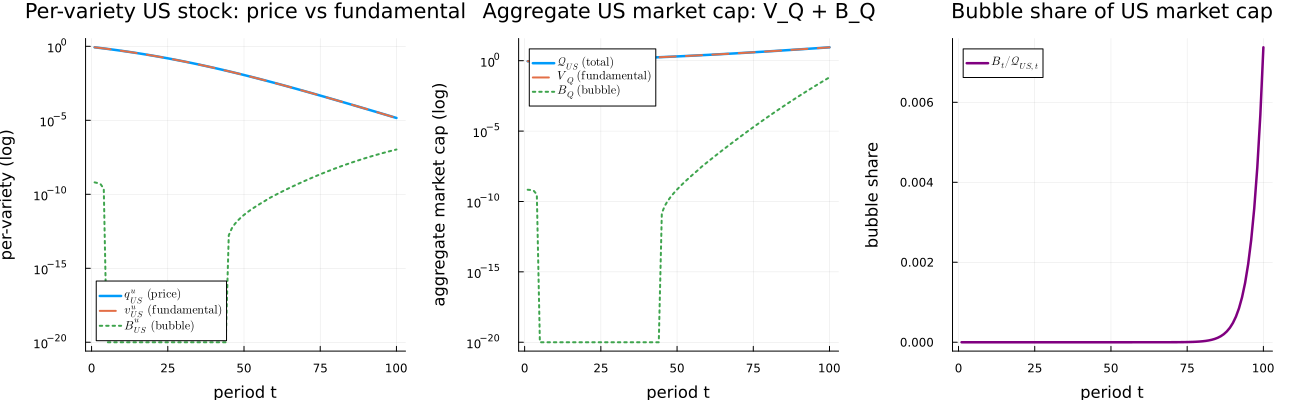

In [4]:
fp1 = plot(tt, q_US, lw=2.5, yscale=:log10, label=L"q_{US}^u\ \mathrm{(price)}",
           xlabel="period t", ylabel="per-variety (log)",
           title="Per-variety US stock: price vs fundamental", legend=:bottomleft)
plot!(fp1, tt, fv.v, lw=2, ls=:dash, label=L"v_{US}^u\ \mathrm{(fundamental)}")
plot!(fp1, tt, max.(fv.B_per, 1e-20), lw=2, ls=:dot, label=L"B_{US}^u\ \mathrm{(bubble)}")

fp2 = plot(tt, Q_US, lw=2.5, yscale=:log10, label=L"\mathcal{Q}_{US}\ \mathrm{(total)}",
           xlabel="period t", ylabel="aggregate market cap (log)",
           title="Aggregate US market cap: V_Q + B_Q", legend=:topleft)
plot!(fp2, tt, fv.V_agg, lw=2, ls=:dash, label=L"V_Q\ \mathrm{(fundamental)}")
plot!(fp2, tt, max.(fv.B_agg, 1e-20), lw=2, ls=:dot, label=L"B_Q\ \mathrm{(bubble)}")

fp3 = plot(tt, fv.bubble_share, lw=2.5, lc=:purple, label=L"B_t/\mathcal{Q}_{US,t}",
           xlabel="period t", ylabel="bubble share",
           title="Bubble share of US market cap")

fig_decomp = plot(fp1, fp2, fp3, layout=(1,3), size=(1300, 400), margin=5Plots.mm)

## 2. NFA Portfolio-Position Components

Before the leakage diagnostics, decompose the stock-clearing NFA identity into its three portfolio-position terms:
$$\mathrm{NFA}_t=(1-\omega_t)(1-\theta_t)A_t-\omega_t^*(1-\theta_{US,t}^*)A_t^*+\theta_tA_t
   = A_t-\mathcal Q_{US,t}.$$

Portfolio-position NFA components  max|sum components − (A−Q_US)| = 2.18e-07
Portfolio shares  ω*: 0.1697→0.0268 | 1−θ_US*: 0.2594→0.7453 | θ: -0.7484→-0.0367


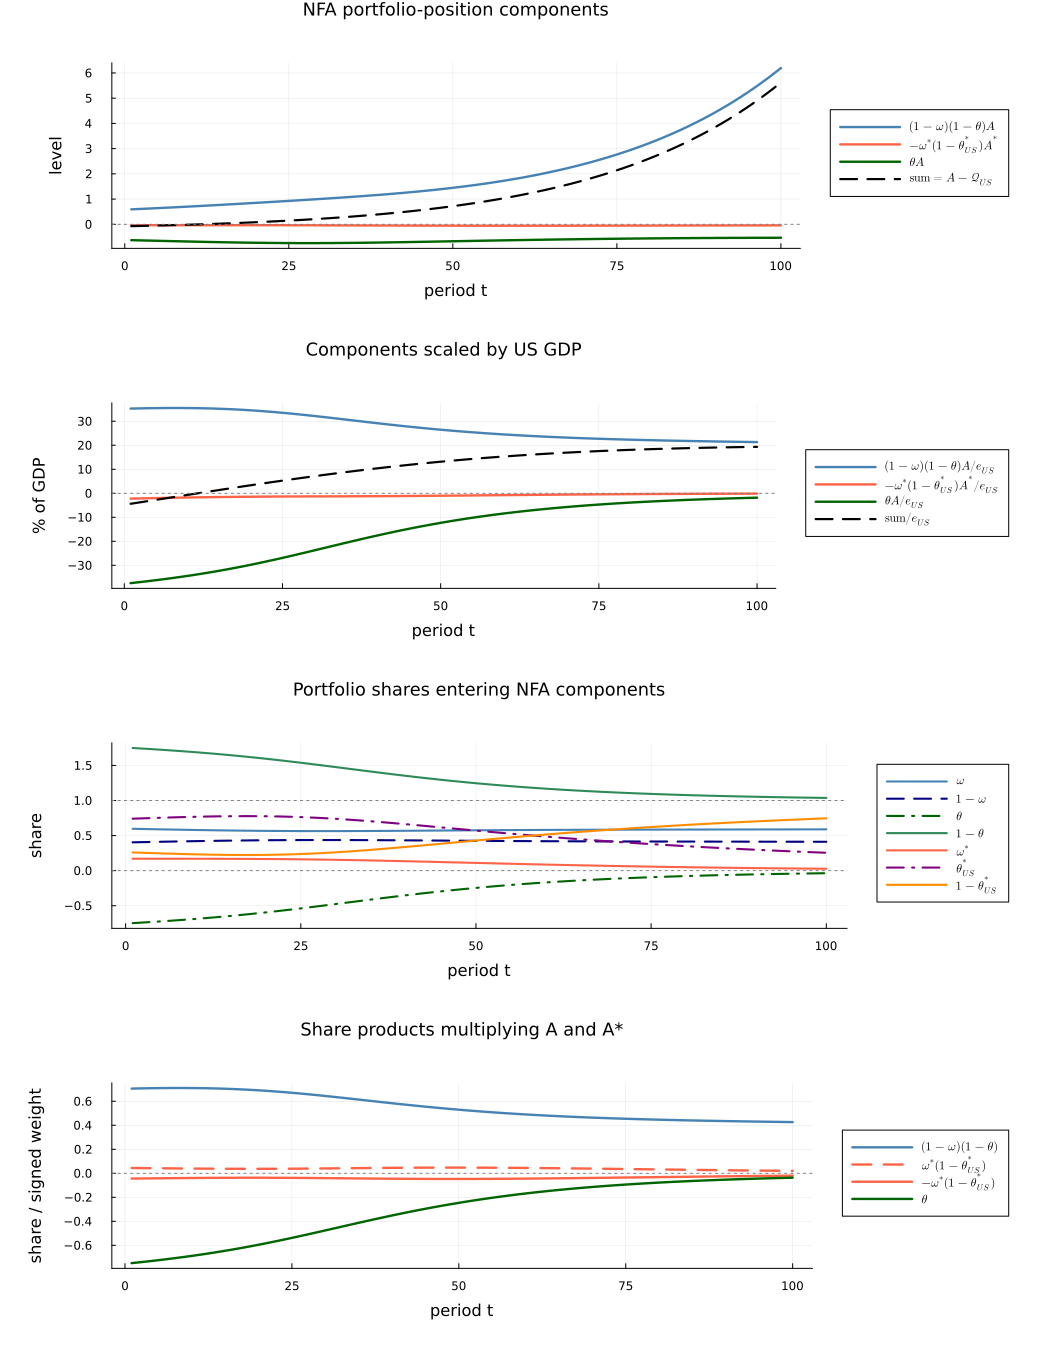

In [5]:
nfa_home_equity   = [(1 - s.ω) * (1 - s.θ) * s.A for s in result.u_path]
nfa_foreign_equity = [-s.ω_star * (1 - s.θ_US_star) * s.A_star for s in result.u_path]
nfa_us_bond       = [s.θ * s.A for s in result.u_path]
nfa_position_sum  = nfa_home_equity .+ nfa_foreign_equity .+ nfa_us_bond

portfolio_ω         = [s.ω for s in result.u_path]
portfolio_ω_star    = [s.ω_star for s in result.u_path]
portfolio_θ         = [s.θ for s in result.u_path]
portfolio_θ_US_star = [s.θ_US_star for s in result.u_path]
share_US_equity     = 1 .- portfolio_ω
share_US_nonbond    = 1 .- portfolio_θ
share_W_US_equity   = portfolio_ω_star
share_W_nonbond     = 1 .- portfolio_θ_US_star

nfa_home_equity_weight    = share_US_equity .* share_US_nonbond
nfa_foreign_equity_weight = share_W_US_equity .* share_W_nonbond
nfa_us_bond_weight        = portfolio_θ

position_err = maximum(abs.(nfa_position_sum .- nf.NFA))
@printf("Portfolio-position NFA components  max|sum components − (A−Q_US)| = %.2e\n", position_err)
@printf("Portfolio shares  ω*: %.4f→%.4f | 1−θ_US*: %.4f→%.4f | θ: %.4f→%.4f\n",
        portfolio_ω_star[1], portfolio_ω_star[end], share_W_nonbond[1], share_W_nonbond[end],
        portfolio_θ[1], portfolio_θ[end])

cp1 = plot(tt, nfa_home_equity, lw=2.4, lc=:steelblue,
           label=L"(1-\omega)(1-\theta)A",
           xlabel="period t", ylabel="level",
           title="NFA portfolio-position components", legend=:outerright,
           titlefontsize=12, left_margin=12Plots.mm, bottom_margin=8Plots.mm)
plot!(cp1, tt, nfa_foreign_equity, lw=2.4, lc=:tomato,
      label=L"-\omega^*(1-\theta_{US}^*)A^*")
plot!(cp1, tt, nfa_us_bond, lw=2.4, lc=:darkgreen,
      label=L"\theta A")
plot!(cp1, tt, nfa_position_sum, lw=2.2, lc=:black, ls=:dash,
      label=L"\mathrm{sum}=A-\mathcal{Q}_{US}")
hline!(cp1, [0.0], lc=:gray, ls=:dot, label="")

cp2 = plot(tt, nfa_home_equity ./ e_u .* 100, lw=2.4, lc=:steelblue,
           label=L"(1-\omega)(1-\theta)A/e_{US}",
           xlabel="period t", ylabel="% of GDP",
           title="Components scaled by US GDP", legend=:outerright,
           titlefontsize=12, left_margin=12Plots.mm, bottom_margin=8Plots.mm)
plot!(cp2, tt, nfa_foreign_equity ./ e_u .* 100, lw=2.4, lc=:tomato,
      label=L"-\omega^*(1-\theta_{US}^*)A^*/e_{US}")
plot!(cp2, tt, nfa_us_bond ./ e_u .* 100, lw=2.4, lc=:darkgreen,
      label=L"\theta A/e_{US}")
plot!(cp2, tt, nfa_position_sum ./ e_u .* 100, lw=2.2, lc=:black, ls=:dash,
      label=L"\mathrm{sum}/e_{US}")
hline!(cp2, [0.0], lc=:gray, ls=:dot, label="")

cp3 = plot(tt, portfolio_ω, lw=2.1, lc=:steelblue,
           label=L"\omega",
           xlabel="period t", ylabel="share",
           title="Portfolio shares entering NFA components", legend=:outerright,
           titlefontsize=12, left_margin=12Plots.mm, bottom_margin=8Plots.mm)
plot!(cp3, tt, share_US_equity, lw=2.1, lc=:navy, ls=:dash,
      label=L"1-\omega")
plot!(cp3, tt, portfolio_θ, lw=2.1, lc=:darkgreen, ls=:dashdot,
      label=L"\theta")
plot!(cp3, tt, share_US_nonbond, lw=2.1, lc=:seagreen,
      label=L"1-\theta")
plot!(cp3, tt, portfolio_ω_star, lw=2.1, lc=:tomato,
      label=L"\omega^*")
plot!(cp3, tt, portfolio_θ_US_star, lw=2.1, lc=:purple, ls=:dashdot,
      label=L"\theta_{US}^*")
plot!(cp3, tt, share_W_nonbond, lw=2.1, lc=:darkorange,
      label=L"1-\theta_{US}^*")
hline!(cp3, [0.0], lc=:gray, ls=:dot, label="")
hline!(cp3, [1.0], lc=:gray, ls=:dot, label="")

cp4 = plot(tt, nfa_home_equity_weight, lw=2.4, lc=:steelblue,
           label=L"(1-\omega)(1-\theta)",
           xlabel="period t", ylabel="share / signed weight",
           title="Share products multiplying A and A*", legend=:outerright,
           titlefontsize=12, left_margin=12Plots.mm, bottom_margin=8Plots.mm)
plot!(cp4, tt, nfa_foreign_equity_weight, lw=2.4, lc=:tomato, ls=:dash,
      label=L"\omega^*(1-\theta_{US}^*)")
plot!(cp4, tt, -nfa_foreign_equity_weight, lw=2.4, lc=:tomato,
      label=L"-\omega^*(1-\theta_{US}^*)")
plot!(cp4, tt, nfa_us_bond_weight, lw=2.4, lc=:darkgreen,
      label=L"\theta")
hline!(cp4, [0.0], lc=:gray, ls=:dot, label="")

fig_nfa_position_components = plot(cp1, cp2, cp3, cp4, layout=(4,1),
                                   size=(1050, 1360), margin=8Plots.mm)


## 3. Detailed Leakage Analysis

From the proof of V4_3 Theorem 1 (`thm_bubble_characterization`), the per-period
bubble **leakage** ratio decomposes as
$$a_t=\underbrace{\frac{d_t^u}{q_t^u}}_{\text{dividend leakage (cond 1a)}}
      +\underbrace{\frac{1-\pi}{\pi}\Big(\frac{C_t^u}{C_t^b}\Big)^{\gamma}
        \frac{q_t^b+d_t^b}{q_t^u}}_{\text{switch leakage (cond 1b)}},$$
with $C_t^z=A_{t-1}^u R_{A,t}^z$ (V4_3 `lem_branch_reduction`). Unlike the
endowment model, the production economy has $C_t^b/C_t^u<1$ throughout: RoW
equity is priced in integrated markets and does **not** hedge the US switch-date
crash (V4_3 `lem_risky_return_bounds`, $R^b_W\asymp R^b_{US}\asymp e^b/e^u$).

Σ a_t = 47.3279 | dividend-leak share = 0.117 | switch-leak share = 0.883


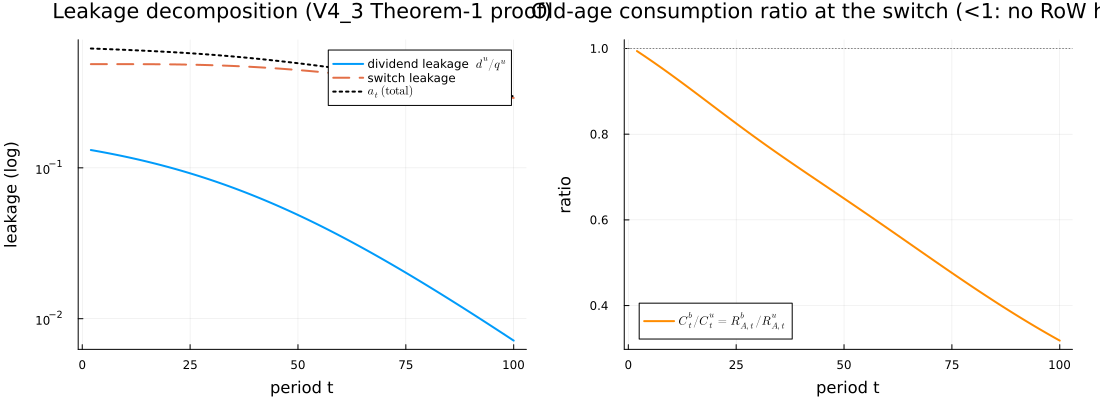

In [6]:
diag = result.diagnostics
div_leak    = diag.cond_1a               # d^u/q^u
switch_leak = diag.a_t .- diag.cond_1a    # switch-branch term
@printf("Σ a_t = %.4f | dividend-leak share = %.3f | switch-leak share = %.3f\n",
        diag.cum_a_t[end], sum(div_leak)/diag.cum_a_t[end],
        sum(switch_leak)/diag.cum_a_t[end])

lp1 = plot(tt[2:end], div_leak[2:end], lw=2, yscale=:log10,
           label="dividend leakage  "*L"d^u/q^u",
           xlabel="period t", ylabel="leakage (log)",
           title="Leakage decomposition (V4_3 Theorem-1 proof)")
plot!(lp1, tt[2:end], switch_leak[2:end], lw=2, ls=:dash, label="switch leakage")
plot!(lp1, tt[2:end], diag.a_t[2:end], lw=2, ls=:dot, lc=:black, label=L"a_t\ \mathrm{(total)}")

cbcu = [result.u_path[t-1].R_A_b / result.u_path[t-1].R_A_u for t in 2:T]
lp2 = plot(2:T, cbcu, lw=2, lc=:darkorange,
           label=L"C_t^b/C_t^u = R_{A,t}^b/R_{A,t}^u",
           xlabel="period t", ylabel="ratio",
           title="Old-age consumption ratio at the switch (<1: no RoW hedge)")
hline!(lp2, [1.0], ls=:dot, lc=:gray, label="")

plot(lp1, lp2, layout=(1,2), size=(1100, 400), margin=5Plots.mm)

## 4. NFA Dynamics and Decomposition

US total NFA (equity + bonds) collapses to $\mathrm{NFA}=A-\mathcal Q_{US}$ with
$A=\beta e_{US}$. We verify the identity, build the realized switch path at
$\tau$, and decompose $\mathrm{NFA}=(A-V_Q)+(-B_Q)$ (the bubble $-B_Q$ is a drag)
together with the gap vs the balanced counterfactual
$\Delta\mathrm{NFA}=(V_Q^b-V_Q^u)+(-B_Q)$.

In [7]:
comp_err = maximum(abs((1-s.ω)*(1-s.θ)*s.A - s.ω_star*(1-s.θ_US_star)*s.A_star +
                       s.θ*s.A - (s.A - s.Q_US)) for s in result.u_path)
@printf("NFA identity  max|(1-ω)(1-θ)A − ω*(1-θ*)A* + θA − (A−Q_US)| = %.2e\n", comp_err)

sim = build_switch_path(result, τ_switch)
Ts  = length(sim)
nfa_gdp_real = [(p.β*s.e_US - s.Q_US)/s.e_US for s in sim]
nfa_gdp_u    = nf.NFA      ./ e_u           # u-path (no switch)
nfa_gdp_b    = nf.NFA_b_cf ./ e_u           # balanced counterfactual

@printf("NFA/GDP   t=1: u=%.4f  b=%.4f | t=%d (last u): u=%.4f\n",
        nfa_gdp_u[1], nfa_gdp_b[1], τ_switch-1, nfa_gdp_u[τ_switch-1])
@printf("Bubble drag −B_Q/GDP   t=40: %+.4f   t=100: %+.4f   (peak %+.4f)\n",
        nf.NFA_bubble[40]/e_u[40], nf.NFA_bubble[100]/e_u[100],
        minimum(nf.NFA_bubble ./ e_u))

NFA identity  max|(1-ω)(1-θ)A − ω*(1-θ*)A* + θA − (A−Q_US)| = 2.18e-07
NFA/GDP   t=1: u=-0.0437  b=-0.0457 | t=39 (last u): u=0.1009
Bubble drag −B_Q/GDP   t=40: +0.0000   t=100: -0.0023   (peak -0.0023)


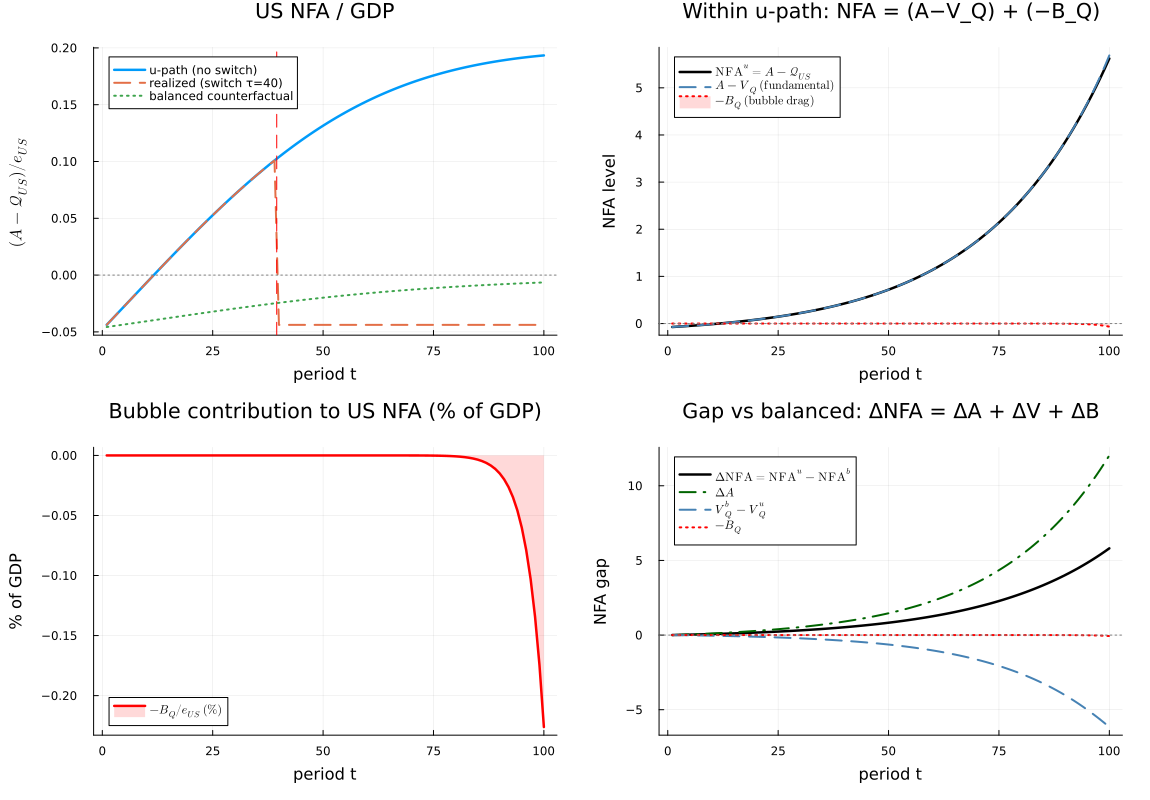

In [8]:
np1 = plot(tt, nfa_gdp_u, lw=2.5, label="u-path (no switch)",
           xlabel="period t", ylabel=L"(A-\mathcal{Q}_{US})/e_{US}",
           title="US NFA / GDP")
plot!(np1, 1:Ts, nfa_gdp_real, lw=2, ls=:dash, label="realized (switch τ=$τ_switch)")
plot!(np1, tt, nfa_gdp_b, lw=2, ls=:dot, label="balanced counterfactual")
vline!(np1, [τ_switch-0.5], lc=:red, ls=:dash, label=""); hline!(np1, [0], lc=:gray, ls=:dot, label="")

np2 = plot(tt, nf.NFA, lw=2.5, lc=:black, label=L"\mathrm{NFA}^u = A - \mathcal{Q}_{US}",
           xlabel="period t", ylabel="NFA level", title="Within u-path: NFA = (A−V_Q) + (−B_Q)")
plot!(np2, tt, nf.NFA_fund, lw=2, ls=:dash, lc=:steelblue, label=L"A - V_Q\ \mathrm{(fundamental)}")
plot!(np2, tt, nf.NFA_bubble, lw=2, ls=:dot, lc=:red, label=L"-B_Q\ \mathrm{(bubble\ drag)}",
      fill=0, fillalpha=0.15, fc=:red)
hline!(np2, [0], lc=:gray, ls=:dot, label="")

np3 = plot(tt, nf.NFA_bubble ./ e_u .* 100, lw=2.5, lc=:red, label=L"-B_Q/e_{US}\ (\%)",
           xlabel="period t", ylabel="% of GDP",
           title="Bubble contribution to US NFA (% of GDP)", fill=0, fillalpha=0.15, fc=:red)

np4 = plot(tt, nf.ΔNFA, lw=2.5, lc=:black, label=L"\Delta\mathrm{NFA}=\mathrm{NFA}^u-\mathrm{NFA}^b",
           xlabel="period t", ylabel="NFA gap", title="Gap vs balanced: ΔNFA = ΔA + ΔV + ΔB")
plot!(np4, tt, nf.ΔA, lw=2, ls=:dashdot, lc=:darkgreen, label=L"\Delta A")
plot!(np4, tt, nf.ΔV, lw=2, ls=:dash, lc=:steelblue, label=L"V_Q^b - V_Q^u")
plot!(np4, tt, nf.ΔB, lw=2, ls=:dot, lc=:red, label=L"-B_Q")
hline!(np4, [0], lc=:gray, ls=:dot, label="")

fig_nfa = plot(np1, np2, np3, np4, layout=(2,2), size=(1150, 800), margin=5Plots.mm)

### 4a. Production & income drivers of the decomposition

Since $\mathrm{NFA}=A-\mathcal Q_{US}=A-(V_Q+B_Q)$, dragging NFA **more negative**
needs a larger US market cap — i.e. larger **dividends**, which lift *both* the
fundamental $V_Q=\mathrm{PV}(d^u)$ and the bubble $B_Q$ (the bubble leaks at rate
$a_t\supset d^u/q^u$, so a bigger dividend base sustains a bigger bubble). This is
the empirically relevant channel: recent US negative NFA is driven by an equity
boom. This block tracks the V4_3 §2 production objects along the u-path,
**recovered from the stored state by exact identities** (no re-solving):

| object | identity | V4_3 eq. |
|---|---|---|
| skilled wage $w_{H,t}$ | $=q^u_t\,a_{US}N_{US,t}$ (free entry) | `country_Q_from_wage` |
| knowledge input $X_t$ | $=\varphi_{US,t}H_{US}$ | `country_X_phi` |
| unskilled wage $w_{L,t}$ | $=(e_{US,t}-w_{H,t}H_{US})/L_{US}$ | `country_labor_income` |
| total dividends $\mathcal D_t$ | $=N_{US,t}d^u_t=\tfrac{1-\vartheta}{\vartheta}w_{H,t}X_t$ | `country_dividend_formula` |
| per-variety yield | $d^u_t/q^u_t=a_{US}\tfrac{1-\vartheta}{\vartheta}\varphi_{US,t}H_{US}$ | `country_dividend_yield` |
| R&D labour share | $1-\varphi_{US,t}$ | `country_knowledge_law` |
| IPO transfer $\mathcal I_t$ | $=(1-\varphi_{US,t})H_{US}w_{H,t}$ | `country_ipo_transfer` |
| output–income | $Y_t=e_{US,t}+\mathcal D_t-\mathcal I_t$ | `country_output_income_identity` |

**What to look for:** with the HKT-literal calibration, total dividends
$\mathcal D_t$ are *small and falling* even as $e_{US}$ grows, because skilled
labour shifts into R&D ($\varphi_{US}\to0$) so the production base $X=\varphi H$
shrinks and income growth accrues to **unskilled wages** $w_L$, not to dividends.
That starves both $V_Q$ and $B_Q$ — the reason NFA stays positive here.

In [9]:
# Recover the V4_3 production block along the u-path (exact identities, no re-solve).
wH     = [s.q_US * p.a_US * s.N_US                       for s in result.u_path]  # skilled wage w_H = q·a·N
wL     = [(s.e_US - s.q_US*p.a_US*s.N_US*p.H_US)/p.L_US  for s in result.u_path]  # unskilled wage w_L
X_US   = [s.φ_US * p.H_US                                for s in result.u_path]  # knowledge input X = φ·H
rd_sh  = [1 - s.φ_US                                     for s in result.u_path]  # R&D labour share 1-φ
D_tot  = [s.N_US * s.d_US                                for s in result.u_path]  # total dividends 𝒟 = N·d
I_ipo  = [s.I_US                                         for s in result.u_path]  # IPO transfer ℐ
Y_out  = [s.Y_US                                         for s in result.u_path]  # final-good output Y
e_inc  = [s.e_US                                         for s in result.u_path]  # young budget income e
dy_per = [s.d_US / s.q_US                                for s in result.u_path]  # per-variety yield d/q
dy_agg = [(s.N_US*s.d_US) / s.Q_US                       for s in result.u_path]  # aggregate yield 𝒟/Q

id_err = maximum(abs.(Y_out .- (e_inc .+ D_tot .- I_ipo)))   # V4_3 country_output_income_identity
@printf("Output–income identity  max|Y − (e + 𝒟 − ℐ)| = %.2e\n\n", id_err)

@printf("%4s %8s %8s %7s | %10s %10s %7s %7s | %9s %9s %9s %9s\n",
        "t","w_H","w_L","1-phi","q_US","d_US","d/q","D/Q","Y","e","D_tot","I_ipo")
println("─"^96)
for t in (1,10,20,30,40,50,60,70,80,90,100)
    s = result.u_path[t]
    @printf("%4d %8.4f %8.4f %7.4f | %10.3e %10.3e %7.4f %7.4f | %9.4f %9.4f %9.4f %9.4f\n",
            t, wH[t], wL[t], rd_sh[t], s.q_US, s.d_US, dy_per[t], dy_agg[t],
            Y_out[t], e_inc[t], D_tot[t], I_ipo[t])
end
println("─"^96)
@printf("Σ: total dividends 𝒟 %.4f→%.4f  |  per-variety yield d/q %.4f→%.4f  |  R&D share 1-φ %.4f→%.4f\n",
        D_tot[1], D_tot[end], dy_per[1], dy_per[end], rd_sh[1], rd_sh[end])
@printf("   skilled wage w_H %.4f→%.4f  |  unskilled wage w_L %.4f→%.4f  (growth concentrates in w_L, not 𝒟)\n",
        wH[1], wH[end], wL[1], wL[end])

Output–income identity  max|Y − (e + 𝒟 − ℐ)| = 7.11e-15

   t      w_H      w_L   1-phi |       q_US       d_US     d/q     D/Q |         Y         e     D_tot     I_ipo
────────────────────────────────────────────────────────────────────────────────────────────────
   1   0.1714   1.5106  0.3362 |  8.570e-01  1.138e-01  0.1328  0.1244 |    1.7382    1.6820    0.1138    0.0576
  10   0.1864   1.8027  0.4071 |  4.928e-01  5.844e-02  0.1186  0.1097 |    2.0237    1.9891    0.1105    0.0759
  20   0.2090   2.2525  0.4943 |  2.352e-01  2.379e-02  0.1011  0.0920 |    2.4638    2.4615    0.1057    0.1033
  30   0.2405   2.8910  0.5859 |  9.788e-02  8.106e-03  0.0828  0.0741 |    3.0902    3.1315    0.0996    0.1409
  40   0.2853   3.8033  0.6754 |  3.565e-02  2.315e-03  0.0649  0.0572 |    3.9885    4.0886    0.0926    0.1927
  50   0.3497   5.1137  0.7564 |  1.153e-02  5.618e-04  0.0487  0.0423 |    5.2841    5.4634    0.0852    0.2645
  60   0.4433   7.0022  0.8244 |  3.382e-03  1.188e-04 

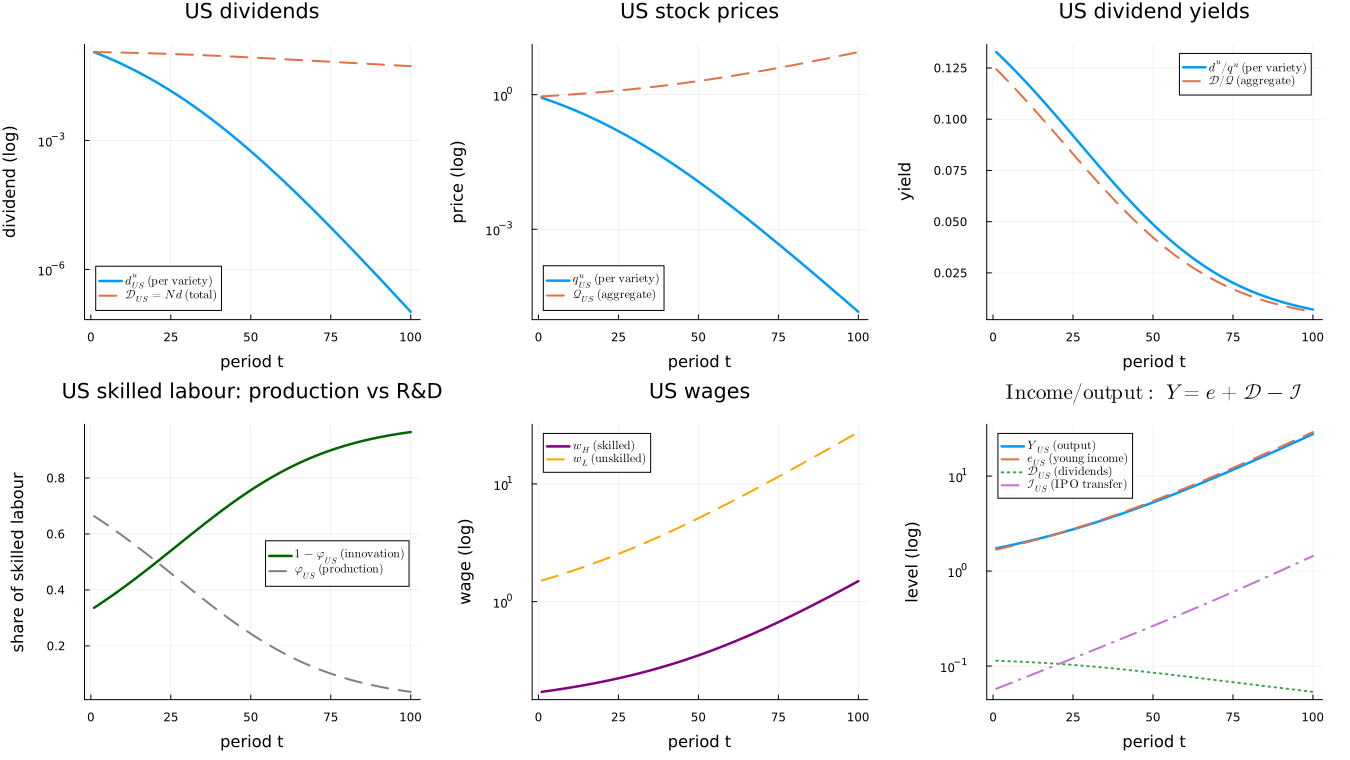

In [10]:
tt = 1:T
pp1 = plot(tt, max.([s.d_US for s in result.u_path], 1e-20), lw=2.5, yscale=:log10,
           label=L"d^u_{US}\ \mathrm{(per\ variety)}", legend=:bottomleft,
           xlabel="period t", ylabel="dividend (log)", title="US dividends")
plot!(pp1, tt, D_tot, lw=2, ls=:dash, label=L"\mathcal{D}_{US}=N\,d\ \mathrm{(total)}")

pp2 = plot(tt, q_US, lw=2.5, yscale=:log10, label=L"q^u_{US}\ \mathrm{(per\ variety)}",
           legend=:bottomleft, xlabel="period t", ylabel="price (log)", title="US stock prices")
plot!(pp2, tt, Q_US, lw=2, ls=:dash, label=L"\mathcal{Q}_{US}\ \mathrm{(aggregate)}")

pp3 = plot(tt, dy_per, lw=2.5, label=L"d^u/q^u\ \mathrm{(per\ variety)}",
           xlabel="period t", ylabel="yield", title="US dividend yields", legend=:topright)
plot!(pp3, tt, dy_agg, lw=2, ls=:dash, label=L"\mathcal{D}/\mathcal{Q}\ \mathrm{(aggregate)}")

pp4 = plot(tt, rd_sh, lw=2.5, lc=:darkgreen, label=L"1-\varphi_{US}\ \mathrm{(innovation)}",
           xlabel="period t", ylabel="share of skilled labour",
           title="US skilled labour: production vs R&D", legend=:right)
plot!(pp4, tt, [s.φ_US for s in result.u_path], lw=2, ls=:dash, lc=:gray,
      label=L"\varphi_{US}\ \mathrm{(production)}")

pp5 = plot(tt, wH, lw=2.5, yscale=:log10, lc=:purple, label=L"w_H\ \mathrm{(skilled)}",
           xlabel="period t", ylabel="wage (log)", title="US wages", legend=:topleft)
plot!(pp5, tt, wL, lw=2, ls=:dash, lc=:orange, label=L"w_L\ \mathrm{(unskilled)}")

pp6 = plot(tt, Y_out, lw=2.5, yscale=:log10, label=L"Y_{US}\ \mathrm{(output)}",
           xlabel="period t", ylabel="level (log)", legend=:topleft,
           title=L"\mathrm{Income/output:}\ Y = e + \mathcal{D} - \mathcal{I}")
plot!(pp6, tt, e_inc, lw=2, ls=:dash, label=L"e_{US}\ \mathrm{(young\ income)}")
plot!(pp6, tt, D_tot, lw=2, ls=:dot,  label=L"\mathcal{D}_{US}\ \mathrm{(dividends)}")
plot!(pp6, tt, I_ipo, lw=2, ls=:dashdot, label=L"\mathcal{I}_{US}\ \mathrm{(IPO\ transfer)}")

fig_prod = plot(pp1, pp2, pp3, pp4, pp5, pp6, layout=(2,3), size=(1350, 760), margin=5Plots.mm)
OUTDIR = "outputs_v43"; isdir(OUTDIR) || mkdir(OUTDIR)
savefig(fig_prod, joinpath(OUTDIR, "production_income_tracking.png"))
fig_prod

## 5. Decomposition Table and Event Study

In [11]:
println("═"^86)
println("Within u-path:  NFA = (A − V_Q) + (−B_Q)")
println("═"^86)
@printf("%4s %13s | %13s %13s | %10s\n","t","NFA","A − V_Q","−B_Q","−B/GDP")
println("─"^86)
for t in (1,10,20,30,40,50,60,70,80,90,100)
    @printf("%4d %13.4e | %13.4e %13.4e | %9.2f%%\n",
            t, nf.NFA[t], nf.NFA_fund[t], nf.NFA_bubble[t], 100*nf.NFA_bubble[t]/e_u[t])
end
println("═"^86)
@printf("Bubble share of US market cap at t=100: %.1f%%   |   bubble drag −B/GDP peak: %.2f%%\n",
        100*fv.bubble_share[100], 100*minimum(nf.NFA_bubble ./ e_u))

══════════════════════════════════════════════════════════════════════════════════════
Within u-path:  NFA = (A − V_Q) + (−B_Q)
══════════════════════════════════════════════════════════════════════════════════════
   t           NFA |       A − V_Q          −B_Q |     −B/GDP
──────────────────────────────────────────────────────────────────────────────────────
   1   -7.3577e-02 |   -7.3577e-02   -6.8200e-10 |     -0.00%
  10   -1.3413e-02 |   -1.3413e-02    1.6040e-10 |      0.00%
  20    8.2522e-02 |    8.2522e-02    8.9586e-11 |      0.00%
  30    2.2222e-01 |    2.2222e-01    4.5613e-11 |      0.00%
  40    4.2511e-01 |    4.2511e-01    7.8937e-12 |      0.00%
  50    7.1848e-01 |    7.1848e-01   -7.0751e-10 |     -0.00%
  60    1.1408e+00 |    1.1408e+00   -6.3932e-08 |     -0.00%
  70    1.7466e+00 |    1.7466e+00   -3.0204e-06 |     -0.00%
  80    2.6140e+00 |    2.6141e+00   -1.1001e-04 |     -0.00%
  90    3.8536e+00 |    3.8566e+00   -3.0658e-03 |     -0.02%
 100    5.6217e+

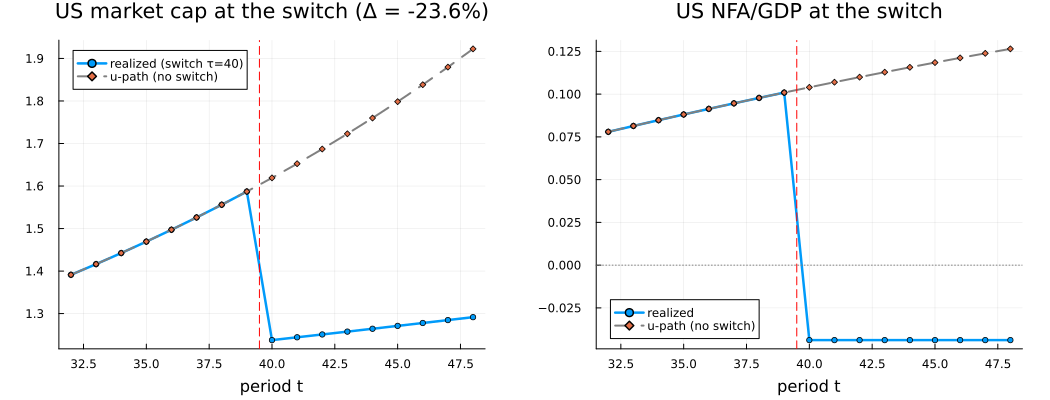

In [12]:
win   = max(1,τ_switch-8):min(Ts,τ_switch+8)
crash = 100*(sim[τ_switch].Q_US - result.u_path[τ_switch].Q_US)/result.u_path[τ_switch].Q_US

ev1 = plot(win, [sim[t].Q_US for t in win], lw=2.5, marker=:circle, ms=3,
           label="realized (switch τ=$τ_switch)", xlabel="period t",
           title="US market cap at the switch (Δ = $(round(crash,digits=1))%)")
plot!(ev1, win, [result.u_path[t].Q_US for t in win], lw=2, ls=:dash, marker=:diamond, ms=3,
      lc=:gray, label="u-path (no switch)")
vline!(ev1, [τ_switch-0.5], lc=:red, ls=:dash, label="")

ev2 = plot(win, nfa_gdp_real[win], lw=2.5, marker=:circle, ms=3, label="realized",
           xlabel="period t", title="US NFA/GDP at the switch")
plot!(ev2, win, nfa_gdp_u[win], lw=2, ls=:dash, marker=:diamond, ms=3, lc=:gray,
      label="u-path (no switch)")
vline!(ev2, [τ_switch-0.5], lc=:red, ls=:dash, label=""); hline!(ev2, [0], lc=:gray, ls=:dot, label="")

plot(ev1, ev2, layout=(1,2), size=(1050, 400), margin=5Plots.mm)

In [13]:
OUTDIR = "outputs_v43"; isdir(OUTDIR) || mkdir(OUTDIR)
open(joinpath(OUTDIR,"nfa_decomposition.csv"),"w") do io
    write(io, "t,N_US,e_US,A,q_US,v,B_per,Q_US,V_agg,B_agg,bubble_share,NFA,NFA_fund,NFA_bubble,NFA_b_cf,dNFA,dA,dV,dB\n")
    for t in 1:T
        s = result.u_path[t]
        write(io, "$t,$(s.N_US),$(s.e_US),$(nf.A[t]),$(s.q_US),$(fv.v[t]),$(fv.B_per[t]),$(nf.Q_US[t]),$(nf.V_agg[t]),$(nf.B_agg[t]),$(fv.bubble_share[t]),$(nf.NFA[t]),$(nf.NFA_fund[t]),$(nf.NFA_bubble[t]),$(nf.NFA_b_cf[t]),$(nf.ΔNFA[t]),$(nf.ΔA[t]),$(nf.ΔV[t]),$(nf.ΔB[t])\n")
    end
end
savefig(fig_decomp, joinpath(OUTDIR, "fundamental_bubble_decomposition.png"))
savefig(fig_nfa_position_components, joinpath(OUTDIR, "nfa_position_components_and_shares.png"))
savefig(fig_nfa,    joinpath(OUTDIR, "nfa_decomposition.png"))
println("✓ Saved nfa_decomposition.csv + 3 PNG figures to ", OUTDIR)

✓ Saved nfa_decomposition.csv + 3 PNG figures to outputs_v43


## Summary

- **Fundamental value decomposition** (V4_3 `effective_US_kernel`):
  $q_{US}=v+B$ and $\mathcal Q_{US}=V_Q+B_Q$ are additive to machine precision,
  with $v>0$. The fundamental recursion is evaluated on the extended scratch-buffer
  path and then trimmed, so the reported bubble share is not pinned by a BGP-at-$T$
  terminal condition.
- **Leakage** $a_t$ is dominated by the **switch-branch term** (cond 1b); the
  dividend term (cond 1a) is small. $C^b/C^u<1$ throughout — RoW equity does not
  hedge the US switch-date crash (integrated markets, V4_3 `lem_risky_return_bounds`).
- **NFA identity** $\mathrm{NFA}=A-\mathcal Q_{US}$ holds (portfolio weights cancel).
  The bubble decomposition $\mathrm{NFA}=(A-V_Q)+(-B_Q)$ isolates the bubble drag
  $-B_Q$ while leaving the full market-cap identity exact.
- The gap decomposition $\Delta\mathrm{NFA}=\Delta A+\Delta V+\Delta B$ separates
  effective endowment/output, fundamental-revaluation, and bubble channels; all are
  exact equilibrium identities.